## ETL

In [1]:
import numpy as np
import pandas as pd

#Read the dataset safely
df = pd.read_csv("Online_Retail.csv", dtype=str)


In [41]:
# Explore data structure
print("Data info:")
print(df.info())
print("\nDescribe numerical columns:")
print(df.describe())
print("\nData typesof the each column:")
print(df.dtypes)
print("\nMissing values in each column:")
print(df.isnull().sum())
print("\nShape of the Data Set:")
print(df.shape)


Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   541909 non-null  Int64         
 7   Country      541909 non-null  object        
dtypes: Int64(1), datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 33.6+ MB
None

Describe numerical columns:
            Quantity                    InvoiceDate      UnitPrice  \
count  541909.000000                         541909  541909.000000   
mean        9.552250  2011-07-04 13:34:57.156386048       4.611114   
min    -80995.000000            2010-12-01 

In [34]:
#CLEANING THE DATA
# Convert data types
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['CustomerID'] = df['CustomerID'].astype('Int64')  # Nullable integer
df['Quantity'] = df['Quantity'].astype(int)
df['UnitPrice'] = df['UnitPrice'].astype(float)

# display the shape of the dataframe
print("\nShape of the Data Set:")
print(df.shape)
print("\nData typesof the each column:")
print(df.dtypes)



Shape of the Data Set:
(541909, 8)

Data typesof the each column:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              Int64
Country                object
dtype: object


In [35]:
# Explore data items
print("\nDisplay first 5 rows:")
with pd.option_context('display.max_columns', None, 'display.width', 1000):
    print(df.head())

# Explore unique values
print("\nDisplay Unique Customers:")
print(df['CustomerID'].nunique())
print("\nDisplay Unique Products:")
print(df['StockCode'].nunique())
print("\nDisplay Unique invoices::")
print(df['InvoiceNo'].nunique())

# Explore negative invoices and valid quantities and prices
print("\nNumber of negative invoices:")
dfc = df[df['InvoiceNo'].astype(str).str.startswith('C')]
with pd.option_context('display.max_columns', None, 'display.width', 1000):
    print(dfc.head())
print(dfc['InvoiceNo'].nunique())

print("\nNumber of invoices with Quantity and UnitPrice > 0 :")
dfqu = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
with pd.option_context('display.max_columns', None, 'display.width', 1000):
    print(dfqu.head())
print(dfqu['InvoiceNo'].nunique())

print("\nShape of the Data Set:")
print(df.shape)


Display first 5 rows:
  InvoiceNo StockCode                          Description  Quantity         InvoiceDate  UnitPrice  CustomerID         Country
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6 2010-12-01 08:26:00       2.55       17850  United Kingdom
1    536365     71053                  WHITE METAL LANTERN         6 2010-12-01 08:26:00       3.39       17850  United Kingdom
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8 2010-12-01 08:26:00       2.75       17850  United Kingdom
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6 2010-12-01 08:26:00       3.39       17850  United Kingdom
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6 2010-12-01 08:26:00       3.39       17850  United Kingdom

Display Unique Customers:
4372

Display Unique Products:
4070

Display Unique invoices::
25900

Number of negative invoices:
    InvoiceNo StockCode                       Description  Quantity         Invoice

In [8]:
# Transform Data 

# Assume negatives are returns or cancellations; for total revenue, consider only positive.
# Remove cancelled orders (InvoiceNo starts with 'C'), negative values
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# display the shape of the dataframe
print("\nTransform Data  : Shape of the Data Set after cleaning the negative or zero value invoices:")
print(df.shape)
    


Transform Data  : Shape of the Data Set after cleaning the negative or zero value invoices:
(530104, 8)


In [9]:
# Feature engineering
df['Revenue'] = df['Quantity'] * df['UnitPrice']
df = df.dropna(subset=['CustomerID']) # For customer-level analysis

# display the shape of the dataframe
print("\nFeature engineering: Shape of the Data Set with the calculated Revenue:")
print(df.shape)


Feature engineering: Shape of the Data Set with the calculated Revenue:
(530104, 9)


In [10]:
# Save cleaned data set
cleaned_df_name = 'cleaned_online_transactions.csv'
df.to_csv(cleaned_df_name, index=False)
print(f"Cleaned dataframe saved as {cleaned_df_name}")

Cleaned dataframe saved as cleaned_online_transactions.csv


## Data Analysis

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

#Read the claned dataset safely
df_clean = pd.read_csv("cleaned_online_transactions.csv", dtype=str)

In [9]:

# Convert data types
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['CustomerID'] = df_clean['CustomerID'].astype('Int64')  # Nullable integer
df_clean['Quantity'] = df_clean['Quantity'].astype(int)
df_clean['UnitPrice'] = df_clean['UnitPrice'].astype(float)
df_clean['Revenue'] = df_clean['Revenue'].astype(float)

# display the shape of the dataframe
print("\nShape of the Data Set:")
print(df.shape)
print("\nData typesof the each column:")
print(df.dtypes)



Shape of the Data Set:
(541909, 8)

Data typesof the each column:
InvoiceNo      object
StockCode      object
Description    object
Quantity       object
InvoiceDate    object
UnitPrice      object
CustomerID     object
Country        object
dtype: object


In [10]:
#TESTING

total_revenue = df_clean['Revenue'].sum()
unique_invoices = int(df_clean['InvoiceNo'].nunique())
avg_transaction_value = total_revenue / unique_invoices
print(f"\nTotal Revenue: {total_revenue}")
print(f"Unique Invoices: {unique_invoices}")
print(f"Average Transaction Value: {avg_transaction_value}")



Total Revenue: 10666684.544
Unique Invoices: 19960
Average Transaction Value: 534.403033266533


Total sales revenue: 10666684.544
Average transaction value: 534.403033266533
Unique customers: 4338
Unique products: 3922
Unique invoices: 19960


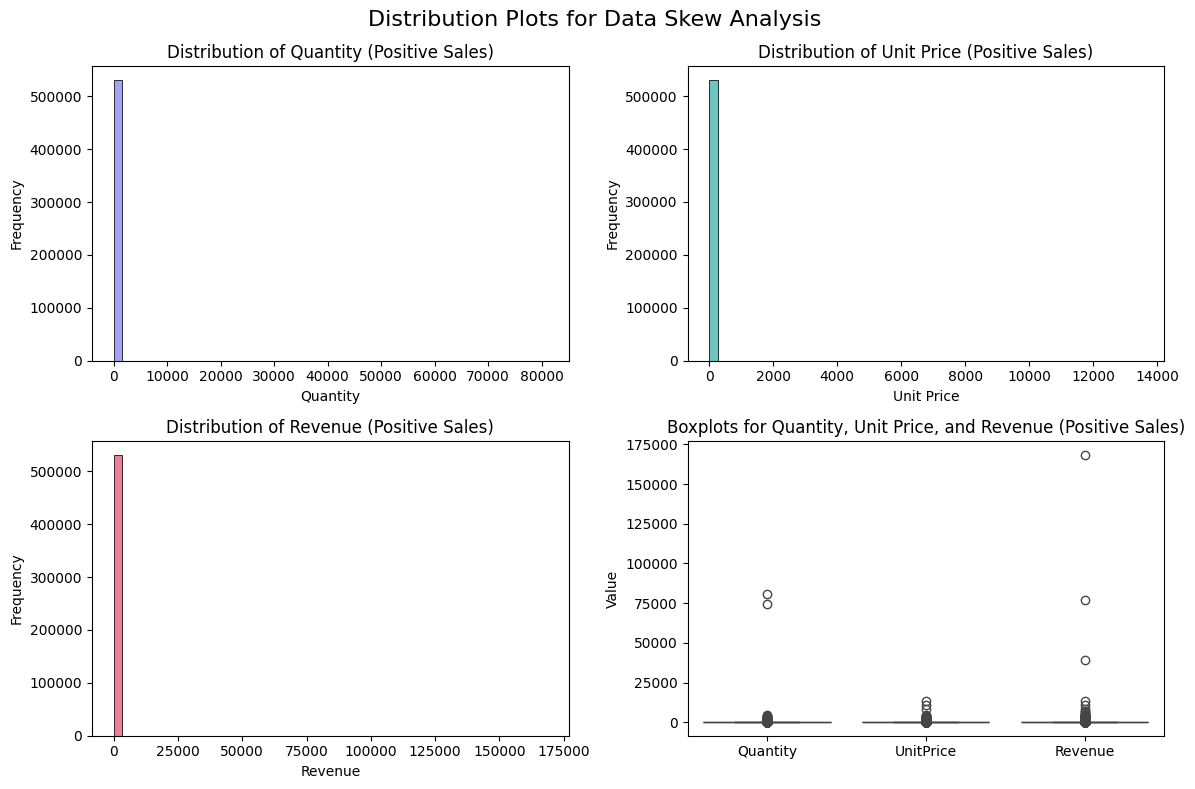

In [42]:
# Descriptive statistics
total_revenue = df_clean['Revenue'].sum()
unique_invoices = df_clean['InvoiceNo'].nunique()
avg_transaction_value = total_revenue / unique_invoices
unique_customers = df_clean['CustomerID'].nunique()
unique_products = df_clean['StockCode'].nunique()

print(f"Total sales revenue: {total_revenue}")
print(f"Average transaction value: {avg_transaction_value}")
print(f"Unique customers: {unique_customers}")
print(f"Unique products: {unique_products}")
print(f"Unique invoices: {unique_invoices}")

# Create distribution plots to identify data skews
figsize = (12, 8)
theme_colors = ['#8686F2', '#38B3AA', '#E85573', '#E59F55', '#E67642', '#5778D3']

# Subplots for distributions
fig, axes = plt.subplots(2, 2, figsize=figsize)
fig.suptitle('Distribution Plots for Data Skew Analysis', fontsize=16)

# Quantity distribution (positive only for sales)
sns.histplot(df_clean['Quantity'], bins=50, ax=axes[0,0], color=theme_colors[0])
axes[0,0].set_title('Distribution of Quantity (Positive Sales)')
axes[0,0].set_xlabel('Quantity')
axes[0,0].set_ylabel('Frequency')

# UnitPrice distribution (positive)
sns.histplot(df_clean['UnitPrice'], bins=50, ax=axes[0,1], color=theme_colors[1])
axes[0,1].set_title('Distribution of Unit Price (Positive Sales)')
axes[0,1].set_xlabel('Unit Price')
axes[0,1].set_ylabel('Frequency')

# Revenue distribution (positive)
sns.histplot(df_clean['Revenue'], bins=50, ax=axes[1,0], color=theme_colors[2])
axes[1,0].set_title('Distribution of Revenue (Positive Sales)')
axes[1,0].set_xlabel('Revenue')
axes[1,0].set_ylabel('Frequency')

# Boxplot for Quantity, UnitPrice, Revenue
sns.boxplot(data=df_clean[['Quantity', 'UnitPrice', 'Revenue']], ax=axes[1,1], palette=theme_colors[:3])
axes[1,1].set_title('Boxplots for Quantity, Unit Price, and Revenue (Positive Sales)')
axes[1,1].set_ylabel('Value')

plt.tight_layout()
plt.show()


In [14]:
#Simple analysis to understand outlier causes
print("=== OUTLIER INVESTIGATION ===")

# 1. Check the most extreme values
print("TOP 10 HIGHEST QUANTITIES:")
high_qty = df_clean.nlargest(10, 'Quantity')[['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'UnitPrice', 'Revenue']]
print(high_qty)
print("\n")

print("TOP 10 HIGHEST UNIT PRICES:")
high_price = df_clean.nlargest(10, 'UnitPrice')[['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'UnitPrice', 'Revenue']]
print(high_price)
print("\n")

print("TOP 10 HIGHEST REVENUE TRANSACTIONS:")
high_revenue = df_clean.nlargest(10, 'Revenue')[['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'UnitPrice', 'Revenue']]
print(high_revenue)
print("\n")

=== OUTLIER INVESTIGATION ===
TOP 10 HIGHEST QUANTITIES:
       InvoiceNo StockCode                          Description  Quantity  \
528623    581483     23843          PAPER CRAFT , LITTLE BIRDIE     80995   
60250     541431     23166       MEDIUM CERAMIC TOP STORAGE JAR     74215   
411713    573008     84077    WORLD WAR 2 GLIDERS ASSTD DESIGNS      4800   
201086    554868     22197                 SMALL POPCORN HOLDER      4300   
95109     544612     22053                EMPIRE DESIGN ROSETTE      3906   
264352    560599     18007  ESSENTIAL BALM 3.5g TIN IN ENVELOPE      3186   
51432     540815     21108   FAIRY CAKE FLANNEL ASSORTED COLOUR      3114   
156615    550461     21108   FAIRY CAKE FLANNEL ASSORTED COLOUR      3114   
423664    573995     16014          SMALL CHINESE STYLE SCISSOR      3000   
4863      536830     84077    WORLD WAR 2 GLIDERS ASSTD DESIGNS      2880   

        UnitPrice    Revenue  
528623       2.08  168469.60  
60250        1.04   77183.60  
41

In [ ]:
 # Check if high quantities are bulk purchases or data errors
print("=== BULK PURCHASE ANALYSIS ===")
bulk_threshold = 5000  # Define what we consider "bulk"
bulk_purchases = df_clean[df_clean['Quantity'] > bulk_threshold]
print(f"Transactions with quantity > {bulk_threshold}: {len(bulk_purchases)}")

if len(bulk_purchases) > 0:
    print("Bulk purchase details:")
    print(bulk_purchases[['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'UnitPrice', 'Revenue']])
    print(f"Total revenue from bulk purchases: £{bulk_purchases['Revenue'].sum():,.2f}")
print("\n")

# Check high-priced items
print("=== HIGH-PRICED ITEMS ANALYSIS ===")
price_threshold = 1000  # Define "high-priced"
high_priced = df_clean[df_clean['UnitPrice'] > price_threshold]
print(f"Items with unit price > £{price_threshold}: {len(high_priced)}")

if len(high_priced) > 0:
    print("High-priced items:")
    print(high_priced[['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'UnitPrice', 'Revenue']].head(10))
print("\n")

# Check specific invoices with extreme values
print("=== INVOICE ANALYSIS ===")
extreme_invoices = df_clean[df_clean['Quantity'].abs() > 5000]['InvoiceNo'].unique()
print(f"Invoices with quantities > 5000: {extreme_invoices}")

for invoice in extreme_invoices[:5]:  # Check extreme invoices
    invoice_data = df_clean[df_clean['InvoiceNo'] == invoice]
    print(f"Invoice {invoice}:")
    print(invoice_data[['StockCode', 'Description', 'Quantity', 'UnitPrice', 'Revenue']])
    print(f"Total invoice value: £{invoice_data['Revenue'].sum():,.2f}")
    print("---")

=== BULK PURCHASE ANALYSIS ===
Transactions with quantity > 5000: 2
Bulk purchase details:
       InvoiceNo StockCode                     Description  Quantity  \
60250     541431     23166  MEDIUM CERAMIC TOP STORAGE JAR     74215   
528623    581483     23843     PAPER CRAFT , LITTLE BIRDIE     80995   

        UnitPrice   Revenue  
60250        1.04   77183.6  
528623       2.08  168469.6  
Total revenue from bulk purchases: £245,653.20


=== HIGH-PRICED ITEMS ANALYSIS ===
Items with unit price > £1000: 54
High-priced items:
       InvoiceNo  StockCode Description  Quantity  UnitPrice   Revenue
14715     537632  AMAZONFEE  AMAZON FEE         1   13541.33  13541.33
40527     539856          M      Manual         1    1298.40   1298.40
114304    546328          M      Manual         1    1687.17   1687.17
114305    546329          M      Manual         1    1687.17   1687.17
116845    546558          M      Manual         1    2583.76   2583.76
141364    548813          M      Manual

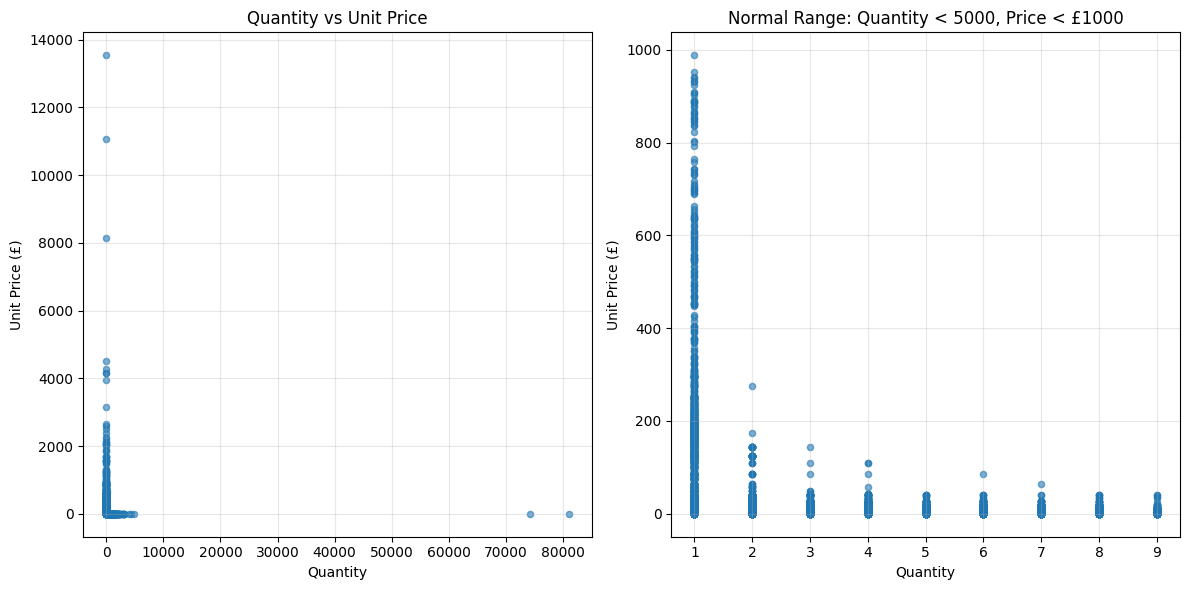

In [ ]:
#Create simple visualizations to understand outlier patterns
    
# 1. Scatter plot: Quantity vs UnitPrice
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(df_clean['Quantity'], df_clean['UnitPrice'], alpha=0.6, s=20)
plt.xlabel('Quantity')
plt.ylabel('Unit Price (£)')
plt.title('Quantity vs Unit Price')
plt.grid(True, alpha=0.3)

# 2. Zoom in on normal range
plt.subplot(1, 2, 2)
normal_range = df_clean[(df_clean['Quantity'] < 10) & (df_clean['UnitPrice'] < 1000)]
plt.scatter(normal_range['Quantity'], normal_range['UnitPrice'], alpha=0.6, s=20)
plt.xlabel('Quantity')
plt.ylabel('Unit Price (£)')
plt.title('Normal Range: Quantity < 5000, Price < £1000')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Interactive Plotly for extreme values
extreme_transactions = df_clean[(df_clean['Quantity'] > 2500) | (df_clean['UnitPrice'] > 1000)]

if len(extreme_transactions) > 0:
    fig = px.scatter(
        extreme_transactions,
        x='Quantity',
        y='UnitPrice',
        size='Revenue',
        color='Revenue',
        hover_data=['InvoiceNo', 'Description', 'Revenue'],
        title='Extreme Transactions Analysis',
        labels={'UnitPrice': 'Unit Price (£)', 'Quantity': 'Purchase Quantity'}
    )
    fig.update_layout(height=500)
    #fig.show()
    # Or show in browser
    #fig.show(renderer='browser')
    

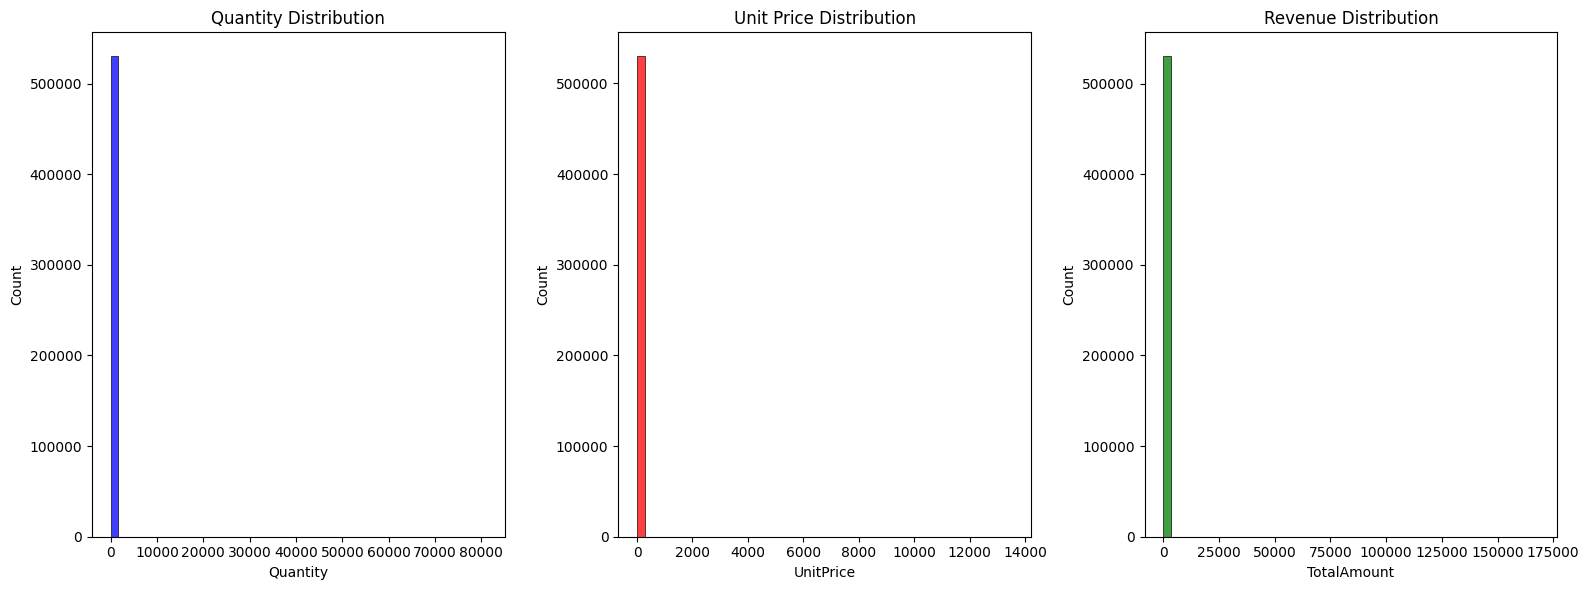

In [ ]:
#Descriptive Statistics
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(16,6))
plt.subplot(1,3,1)
sns.histplot(df['Quantity'], bins=50, color='blue')
plt.title('Quantity Distribution')
plt.subplot(1,3,2)
sns.histplot(df['UnitPrice'], bins=50, color='red')
plt.title('Unit Price Distribution')
plt.subplot(1,3,3)
sns.histplot(df['TotalAmount'], bins=50, color='green')
plt.title('Revenue Distribution')
plt.tight_layout()
plt.show()

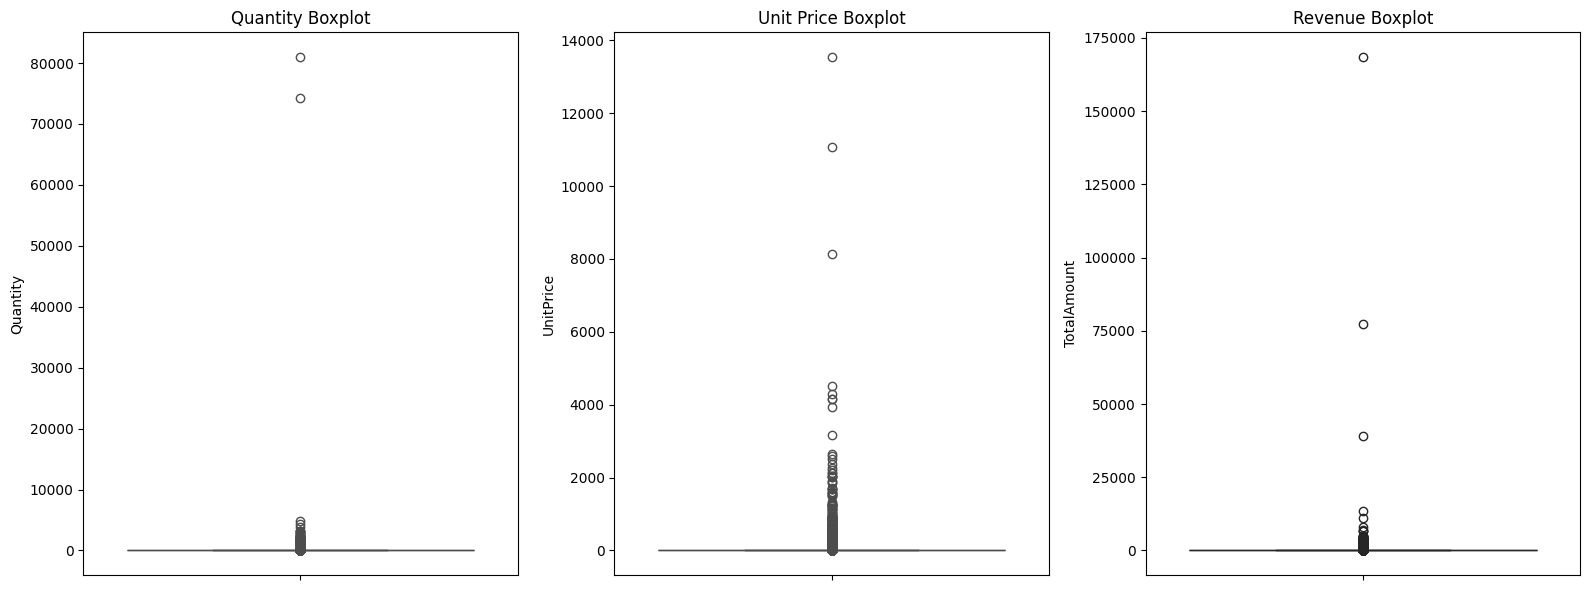

In [11]:
#Plot a blox plot for UnitPrice, qualtity and revenue
plt.figure(figsize=(16,6))
plt.subplot(1,3,1)
sns.boxplot(y=df['Quantity'], color='blue')
plt.title('Quantity Boxplot')
plt.subplot(1,3,2)
sns.boxplot(y=df['UnitPrice'], color='red')
plt.title('Unit Price Boxplot')
plt.subplot(1,3,3)
sns.boxplot(y=df['TotalAmount'], color='green')
plt.title('Revenue Boxplot')
plt.tight_layout()
plt.show()

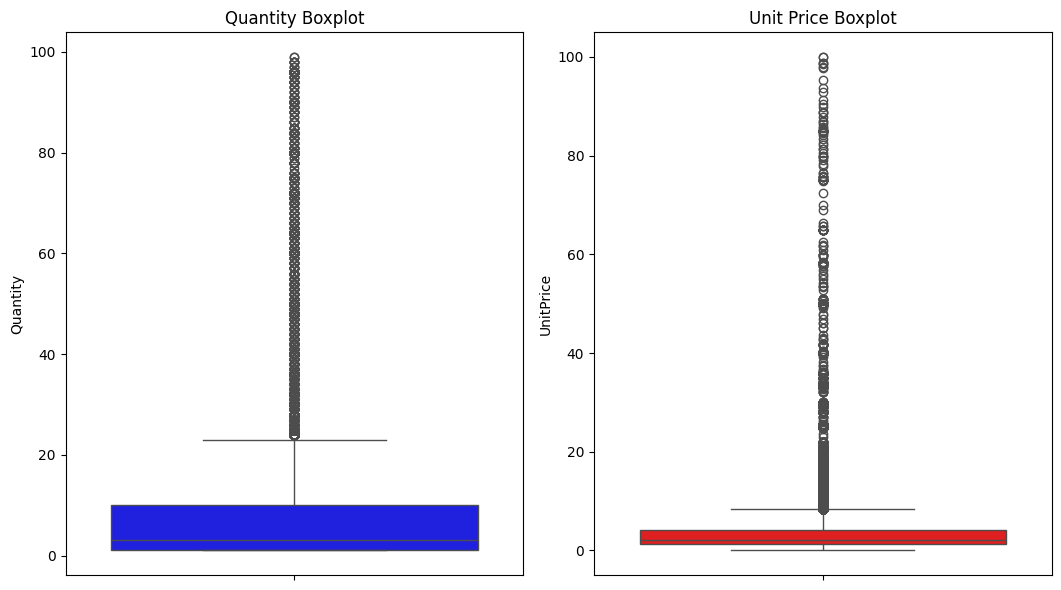

In [27]:
normal_quntity_range = df_clean[(df_clean['Quantity'] < 100)]
normal_price_range = df_clean[(df_clean['UnitPrice'] < 100)]

#Plot a blox plot for UnitPrice, qualtity and revenue
plt.figure(figsize=(16,6))
plt.subplot(1,3,1)
sns.boxplot(y=normal_quntity_range['Quantity'], color='blue')
plt.title('Quantity Boxplot')
plt.subplot(1,3,2)
sns.boxplot(y=normal_price_range['UnitPrice'], color='red')
plt.title('Unit Price Boxplot')
# plt.subplot(1,3,3)
# sns.boxplot(y=df['TotalAmount'], color='green')
# plt.title('Revenue Boxplot')
plt.tight_layout()
plt.show()

The majority of transactions involve small quantities and low unit prices, but there are heavy outliers. Most revenue is from a small number of large-size purchases. This indicates a very skewed sales structure where a few sales dominate the business.

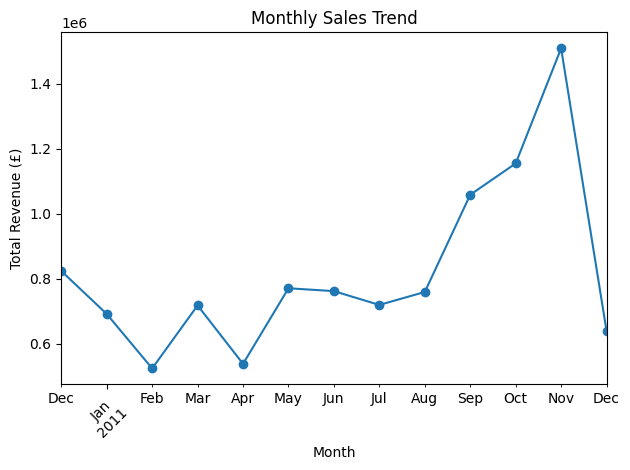

In [12]:
#Sales trend over time
import matplotlib.pyplot as plt

monthly_sales = df.groupby(df['InvoiceDate'].dt.to_period('M'))['TotalAmount'].sum()
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales Trend')
plt.ylabel('Total Revenue (£)')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Sales peak towards end-of-year, indicating strong holiday and seasonal effects. Business should focus marketing/promotions in these high-activity months.

In [31]:
#Customer Analysis | Segmentation

def rfm_analysis(df):
    reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
    rfm = df.groupby('CustomerID').agg({
        'InvoiceDate': lambda x: (reference_date - x.max()).days,
        'InvoiceNo': 'nunique',
        'Revenue': 'sum'
    }).reset_index()
    rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']
    return rfm

import plotly.express as px
import nbformat
rfm = rfm_analysis(df_clean)
rfm['Segment'] = pd.qcut(rfm['Monetary'], 4, labels=['Low', 'Mid', 'High', 'Top'])
fig = px.scatter(rfm, x='Frequency', y='Monetary', color='Segment',
                 title='Customer Segmentation - RFM (Plotly Interactive)')

#fig.show()

"Top" monetary customers are both highly active and have high spend. These are prime targets for loyalty programs and personalized offers. "Low" segment may need re-engagement strategies.

In [32]:
top_products = df_clean.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)
fig = px.bar(top_products, x=top_products.index, y=top_products.values,
             labels={'x':'Product', 'y':'Revenue (£)'}, title='Top 10 Products by Revenue')
#fig.show()

A small handful of products account for most sales. Stock and promotional focus should emphasize these core offerings.

In [43]:
# Filter negative quantities (returns)
returns_df = df[df['Quantity'] < 0].copy()
returns_df['Revenue'] = returns_df['Quantity'] * returns_df['UnitPrice']

print(f"Total return transactions: {len(returns_df)}")
print(f"Total items returned: {returns_df['Quantity'].sum() * -1:,.0f}")  # Convert to positive

# 1. MOST RETURNED ITEMS
print("\n" + "="*50)
print("MOST RETURNED ITEMS")
print("="*50)

most_returned_items = returns_df.groupby(['StockCode', 'Description']).agg({
    'Quantity': 'sum',  # This will be negative
    'InvoiceNo': 'nunique',  # Number of return transactions
    'CustomerID': 'nunique'  # Number of unique customers returning
}).reset_index()

# Convert quantity to positive for easier interpretation
most_returned_items['Total_Returned_Qty'] = most_returned_items['Quantity'] * -1
most_returned_items = most_returned_items.sort_values('Total_Returned_Qty', ascending=False)

print("\nTop 10 Most Returned Items:")
print(most_returned_items[['StockCode', 'Description', 'Total_Returned_Qty', 'InvoiceNo', 'CustomerID']].head(10).to_string(index=False))

# 2. CUSTOMERS WITH MOST RETURNS
print("\n" + "="*50)
print("CUSTOMERS WITH MOST RETURNS")
print("="*50)

customer_returns = returns_df.groupby('CustomerID').agg({
    'Quantity': 'sum',  # Total returned quantity
    'InvoiceNo': 'nunique',  # Number of return transactions
    'Revenue': 'sum',  # Total refund amount (should be negative)
    'Country': 'first'  # Assuming same country per customer
}).reset_index()

customer_returns['Total_Returned_Qty'] = customer_returns['Quantity'] * -1
customer_returns['Total_Refund_Amount'] = customer_returns['Revenue'] * -1
customer_returns = customer_returns.sort_values('Total_Returned_Qty', ascending=False)

print("\nTop 10 Customers by Returns Quantity:")
print(customer_returns[['CustomerID', 'Total_Returned_Qty', 'InvoiceNo', 'Total_Refund_Amount', 'Country']].head(10).to_string(index=False))

# 3. ANALYZE RETURN PATTERNS
print("\n" + "="*50)
print("RETURN PATTERNS ANALYSIS")
print("="*50)

# Check if returns have corresponding original purchases
returns_df['InvoiceNo_Original'] = returns_df['InvoiceNo'].str.replace('C', '')
returns_with_original = returns_df[returns_df['InvoiceNo_Original'].isin(df['InvoiceNo'])]

print(f"Returns with matching original invoices: {len(returns_with_original)}")
print(f"Returns without matching original invoices: {len(returns_df) - len(returns_with_original)}")

# 4. TEMPORAL ANALYSIS OF RETURNS
print("\n" + "="*50)
print("RETURNS OVER TIME")
print("="*50)

returns_df['InvoiceDate'] = pd.to_datetime(returns_df['InvoiceDate'])
returns_df['Month'] = returns_df['InvoiceDate'].dt.to_period('M')

monthly_returns = returns_df.groupby('Month').agg({
    'Quantity': 'sum',
    'InvoiceNo': 'nunique',
    'CustomerID': 'nunique'
}).reset_index()

monthly_returns['Total_Returned_Qty'] = monthly_returns['Quantity'] * -1
monthly_returns['Month'] = monthly_returns['Month'].dt.strftime('%Y-%m')

print("\nMonthly Returns Pattern:")
print(monthly_returns[['Month', 'Total_Returned_Qty', 'InvoiceNo', 'CustomerID']].to_string(index=False))

Total return transactions: 10624
Total items returned: 484,531

MOST RETURNED ITEMS

Top 10 Most Returned Items:
StockCode                         Description  Total_Returned_Qty  InvoiceNo  CustomerID
    23843         PAPER CRAFT , LITTLE BIRDIE               80995          1           1
    23166      MEDIUM CERAMIC TOP STORAGE JAR               74494         10          10
    23005        printing smudges/thrown away               19200          2           1
    84347 ROTATING SILVER ANGELS T-LIGHT HLDR                9376          4           4
    23003        Printing smudges/thrown away                9058          1           1
   72140F                          throw away                5368          1           1
   79323W              Unsaleable, destroyed.                4830          1           1
        M                              Manual                4066        223         113
    21108  FAIRY CAKE FLANNEL ASSORTED COLOUR                3150          3          

In [40]:


# Analyze potential reasons for returns
print("\n" + "="*50)
print("🔎 POTENTIAL RETURN REASONS ANALYSIS")
print("="*50)

# A. High-value item returns
high_value_returns = returns_df[returns_df['UnitPrice'] > 50]
print(f"High-value returns (>£50): {len(high_value_returns)} transactions")

# B. Bulk returns (large quantities)
bulk_returns = returns_df[returns_df['Quantity'] < -10]  # More than 10 items returned
print(f"Bulk returns (>10 items): {len(bulk_returns)} transactions")

# C. Frequent returners
frequent_returners = customer_returns[customer_returns['InvoiceNo'] > 5]
print(f"Frequent returners (>5 return transactions): {len(frequent_returners)} customers")

# D. Return patterns by country
country_returns = returns_df.groupby('Country').agg({
    'Quantity': 'sum',
    'InvoiceNo': 'nunique',
    'CustomerID': 'nunique'
}).reset_index()
country_returns['Total_Returned_Qty'] = country_returns['Quantity'] * -1
country_returns = country_returns.sort_values('Total_Returned_Qty', ascending=False)

print("\nReturns by Country:")
print(country_returns[['Country', 'Total_Returned_Qty', 'InvoiceNo', 'CustomerID']].head(10).to_string(index=False))


🔎 POTENTIAL RETURN REASONS ANALYSIS
High-value returns (>£50): 286 transactions
Bulk returns (>10 items): 2610 transactions
Frequent returners (>5 return transactions): 107 customers

Returns by Country:
       Country  Total_Returned_Qty  InvoiceNo  CustomerID
United Kingdom              469990       4708        1411
          EIRE                4810         72           4
       Germany                1815        146          55
        France                1624         69          32
           USA                1424          2           2
         Spain                1127         15          12
   Netherlands                 809          6           4
         Japan                 798          9           3
     Australia                 556         12           4
        Sweden                 446         10           3
